# Alarm data

In [1]:
import random
import time

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import chisq

import pandas as pd
import cslearn.scoring as sc
import cslearn.learning as ctl
import cslearn.ldag as ldag
import numpy as np

%load_ext autoreload
%autoreload 2

/home/alex/projects/cstrees/code/.devenv/state/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Read data

In [2]:
alarmdf = pd.read_csv('../data/alarm_data.csv')
alarmdf = alarmdf.drop(columns=['Unnamed: 0'])
alarmdf.head()

,CVP,PCWP,HIST,TPR,BP,CO,HRBP,HREK,HRSA,PAP,...,ERLO,HR,ERCA,SHNT,PVS,ACO2,VALV,VLNG,VTUB,VMCH
0,NORMAL,NORMAL,False,LOW,NORMAL,HIGH,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,NORMAL,NORMAL,HIGH,LOW,ZERO,NORMAL
1,NORMAL,NORMAL,False,NORMAL,LOW,LOW,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,LOW,LOW,ZERO,ZERO,LOW,NORMAL
2,NORMAL,HIGH,False,NORMAL,NORMAL,HIGH,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,LOW,LOW,ZERO,ZERO,LOW,NORMAL
3,NORMAL,NORMAL,False,LOW,LOW,HIGH,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,NORMAL,LOW,ZERO,ZERO,LOW,NORMAL
4,NORMAL,NORMAL,False,LOW,LOW,NORMAL,HIGH,HIGH,HIGH,NORMAL,...,False,HIGH,False,NORMAL,LOW,LOW,ZERO,ZERO,LOW,NORMAL


Convert all the outcomes into numeric values.

In [3]:
alarmnp = alarmdf.to_numpy()
alarmnp[:,0] = [0 for i in range(20000)]

def convertToNumeric(df):
    npdf = df.to_numpy()
    vars = list(df.columns)
    n = len(df)
    for v in vars:
        j = vars.index(v)
        states = list(alarmdf[v].drop_duplicates().to_numpy())
        for i in range(n):
            npdf[i,j] = states.index(alarmdf[v].iloc[i])
    numdf = pd.DataFrame(npdf)
    return numdf

numalarmdf = convertToNumeric(alarmdf)

cards_row = {0 : 3, 1 : 3, 2 : 2, 3 : 3, 4 : 3, 5 : 3, 6 : 3, 7 : 3, 8 : 3, 9 : 3, 10 : 3, 11 : 2, 12 : 4, 13 : 4, 14 : 4, 15 : 3, 16 : 2, 17 : 2, 18 : 2, 19 : 2, 20 : 2, 21 : 3, 22 : 2, 23 : 2, 24 : 3, 25 : 3, 26 : 2, 27 : 2, 28 : 3, 29 : 2, 30 : 2, 31 : 3, 32 : 3, 33 : 4, 34 : 4, 35 : 4, 36 : 4}
numalarmdf.loc[len(numalarmdf)] = cards_row
target_row = 20000
# Move target row to first element of list.
idx = [target_row] + [i for i in range(len(numalarmdf)) if i != target_row]
numalarmdf.iloc[idx]
numalarmdf_cards = numalarmdf.iloc[idx].reset_index(drop=True)
numalarmdf_cards.columns = alarmdf.columns

## MCMC sampling

We run the PC algorithm to estimate a CPDAG that is used to restrict the possible context variables.

In [4]:
np.random.seed(1)
random.seed(1)
start = time.time()
pcgraph = pc(numalarmdf_cards[1:].values, 0.05, "chisq", node_names=numalarmdf_cards.columns)
poss_cvars = ctl.causallearn_graph_to_posscvars(pcgraph, labels=numalarmdf_cards.columns)
#print("Possible context variables per node:", poss_cvars)

score_table, context_scores, context_counts = sc.order_score_tables(numalarmdf_cards,
                                                                    max_cvars=2,
                                                                    alpha_tot=1.0,
                                                                    method="BDeu",
                                                                    poss_cvars=poss_cvars)

orders, scores = ctl.gibbs_order_sampler(5000, score_table)
end = time.time()
print('Computation time in seconds:', end - start)

  0%|          | 0/37 [00:00<?, ?it/s]

  0%|          | 0/37 [00:00<?, ?it/s]

Depth=0, working on node 0:   3%|▎         | 1/37 [00:00<00:00, 1115.21it/s]

Depth=0, working on node 1:   5%|▌         | 2/37 [00:00<00:00, 184.80it/s] 

Depth=0, working on node 2:   8%|▊         | 3/37 [00:00<00:00, 136.63it/s]

...

Gibbs order sampler:  79%|███████▉  | 3956/5000 [00:01<00:00, 3402.70it/s]

Gibbs order sampler:  87%|████████▋ | 4329/5000 [00:01<00:00, 3497.67it/s]

Gibbs order sampler:  94%|█████████▎| 4681/5000 [00:01<00:00, 3496.61it/s]

Gibbs order sampler: 100%|██████████| 5000/5000 [00:01<00:00, 3506.51it/s]

Computation time in seconds: 3.6138370037078857


In [5]:
# optimal variable ordering
alarmmaporder = orders[scores.index(max(scores))]
#print(alarmmaporder)

In [6]:
# get optimal tree for ordering
alarmopttree = ctl._optimal_cstree_given_order(alarmmaporder, context_scores)

## LDAG representation

In [7]:
LDAG = alarmopttree.to_LDAG()

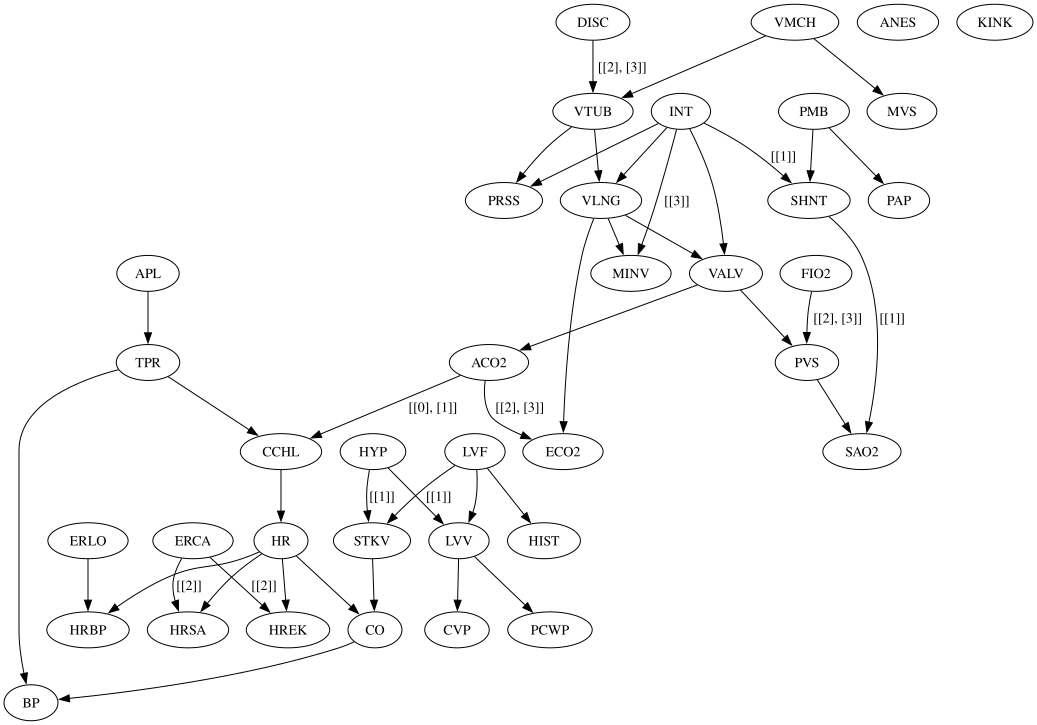

In [8]:
agraph = LDAG.plot_graphviz()
agraph
#agraph.draw('alarm_CStree_LDAG.png')

## Baseline: plain DAG (PC only), SHD vs. the true ALARM network

As a non-CSI baseline, we compare a plain DAG learned by PC alone (no CSlearn context-specific refinement) against the true ALARM network structure, and compare that SHD to the SHD of CSlearn's LDAG (converted from its learned CStree, as above) against the same ground truth.

The true ALARM network structure is fetched from the bnlearn repository via `pgmpy`; its node names are relabeled to the abbreviated variable codes used throughout this notebook (matching the descriptions in the accompanying variable table).

In [9]:
from pgmpy.utils import get_example_model
from cslearn.evaluate import shd_edges

# Maps bnlearn's full node names to the abbreviated codes used in this
# notebook (see the variable table in the paper's supplement for the
# descriptions).
long_to_abbrev = {
    "CVP": "CVP", "PCWP": "PCWP", "HISTORY": "HIST", "TPR": "TPR", "BP": "BP", "CO": "CO",
    "HRBP": "HRBP", "HREKG": "HREK", "HRSAT": "HRSA", "PAP": "PAP", "SAO2": "SAO2",
    "FIO2": "FIO2", "PRESS": "PRSS", "EXPCO2": "ECO2", "MINVOL": "MINV", "MINVOLSET": "MVS",
    "HYPOVOLEMIA": "HYP", "LVFAILURE": "LVF", "ANAPHYLAXIS": "APL", "INSUFFANESTH": "ANES",
    "PULMEMBOLUS": "PMB", "INTUBATION": "INT", "KINKEDTUBE": "KINK", "DISCONNECT": "DISC",
    "LVEDVOLUME": "LVV", "STROKEVOLUME": "STKV", "CATECHOL": "CCHL", "ERRLOWOUTPUT": "ERLO",
    "HR": "HR", "ERRCAUTER": "ERCA", "SHUNT": "SHNT", "PVSAT": "PVS", "ARTCO2": "ACO2",
    "VENTALV": "VALV", "VENTLUNG": "VLNG", "VENTTUBE": "VTUB", "VENTMACH": "VMCH",
}

true_alarm_model = get_example_model("alarm")
true_edges = {(long_to_abbrev[u], long_to_abbrev[v]) for u, v in true_alarm_model.edges()}
print(f"True ALARM network: {true_alarm_model.number_of_nodes()} nodes, {len(true_edges)} edges")

True ALARM network: 37 nodes, 46 edges


In [10]:
pc_dag_df = ctl.causallearn_graph_to_dag(pcgraph, labels=numalarmdf_cards.columns, alg="pc")
pc_edges = {(u, v) for u in pc_dag_df.index for v in pc_dag_df.columns if pc_dag_df.loc[u, v] == 1}

cslearn_edges = set(LDAG.edges())

pc_shd = shd_edges(pc_edges, true_edges)
cslearn_shd = shd_edges(cslearn_edges, true_edges)

print(f"PC-only DAG:   {len(pc_edges)} edges, SHD vs. true = {pc_shd}")
print(f"CSlearn's LDAG: {len(cslearn_edges)} edges, SHD vs. true = {cslearn_shd}")

PC-only DAG:   44 edges, SHD vs. true = 5
CSlearn's LDAG: 42 edges, SHD vs. true = 5
